### Projeto Final TI0119 - Circuitos Elétricos | Parte I
---
# Filtro RC Passa-Baixas para arquivos de aúdio
### Simulação digital e experimentação analógica

Equipe: Francisco, Giovanni e Nathália

## Configurações e Imports

In [1]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
import sounddevice as sd
import soundfile as sf
from scipy.signal import butter, lfilter

# Standardize plot sizes and styles
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['image.cmap'] = 'magma'

# -----------------------------------------------------------------------
# SPECTROGRAM & DIGITAL FILTER FUNCTIONS
# -----------------------------------------------------------------------

def apply_filter(
        audio: np.ndarray, 
        sr: int,
        low_cutoff: float = None, 
        high_cutoff: float = None
    ) -> np.ndarray:
    """
    Applies a 1st-order IIR Butterworth filter to simulate the 
    responses of an RC passive circuit (-20 dB/decade roll-off).
    
    Parameters:
    - audio: The input audio array.
    - sr: Sample rate (e.g., 48000).
    - low_cutoff: Frequency (Hz) below which audio is cut (High-Pass Filter).
    - high_cutoff: Frequency (Hz) above which audio is cut (Low-Pass Filter).
    
    If both cutoffs are provided, they are applied sequentially (Band-Pass).
    """   
    # Create a copy to prevent modifying the original array
    audio_filtered = audio.copy()
    
    # N=1 strictly enforces the 1st-order physical behavior
    if low_cutoff is not None:
        b, a = butter(N=1, Wn=low_cutoff, btype='highpass', fs=sr)
        audio_filtered = lfilter(b, a, audio_filtered)
        
    if high_cutoff is not None:
        b, a = butter(N=1, Wn=high_cutoff, btype='lowpass', fs=sr)
        audio_filtered = lfilter(b, a, audio_filtered)
        
    return audio_filtered

def plot_spectrogram(
        audio_data: np.ndarray, 
        sr: int, 
        title: str = "Spectrogram - Raw Audio"
    ) -> None:
    """Calculates and plots the standard spectrogram of an audio signal."""
    # Calculate Short-Time Fourier Transform (STFT)
    stft_mag = np.abs(librosa.stft(audio_data))
    db_spectrogram = librosa.amplitude_to_db(stft_mag, ref=np.max)
    
    plt.figure()
    librosa.display.specshow(db_spectrogram, sr=sr, x_axis='time', y_axis='hz')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

def save(audio_data: np.ndarray, sr: int, pasta_destino: str, nome_arquivo: str) -> None:
    os.makedirs(pasta_destino, exist_ok=True)

    if not nome_arquivo.endswith('.wav'):
        nome_arquivo += '.wav'
    caminho_completo = os.path.join(pasta_destino, nome_arquivo)
    
    sf.write(caminho_completo, audio_data, sr, subtype='FLOAT')
    print(f"Audio saved successfully")

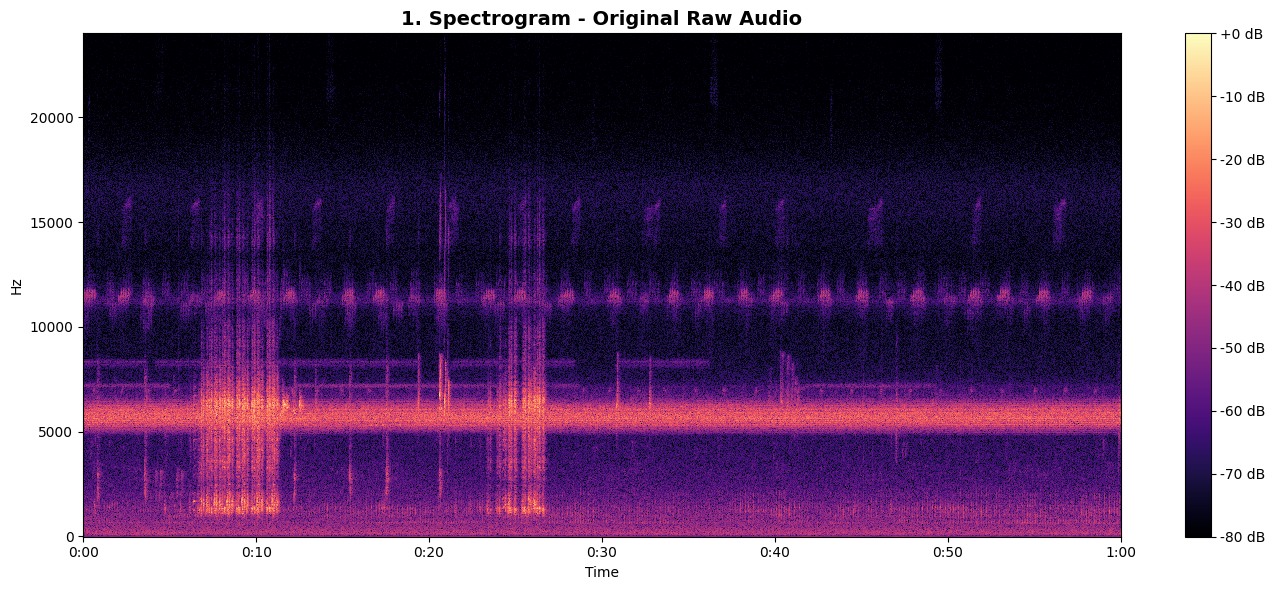

Audio saved successfully


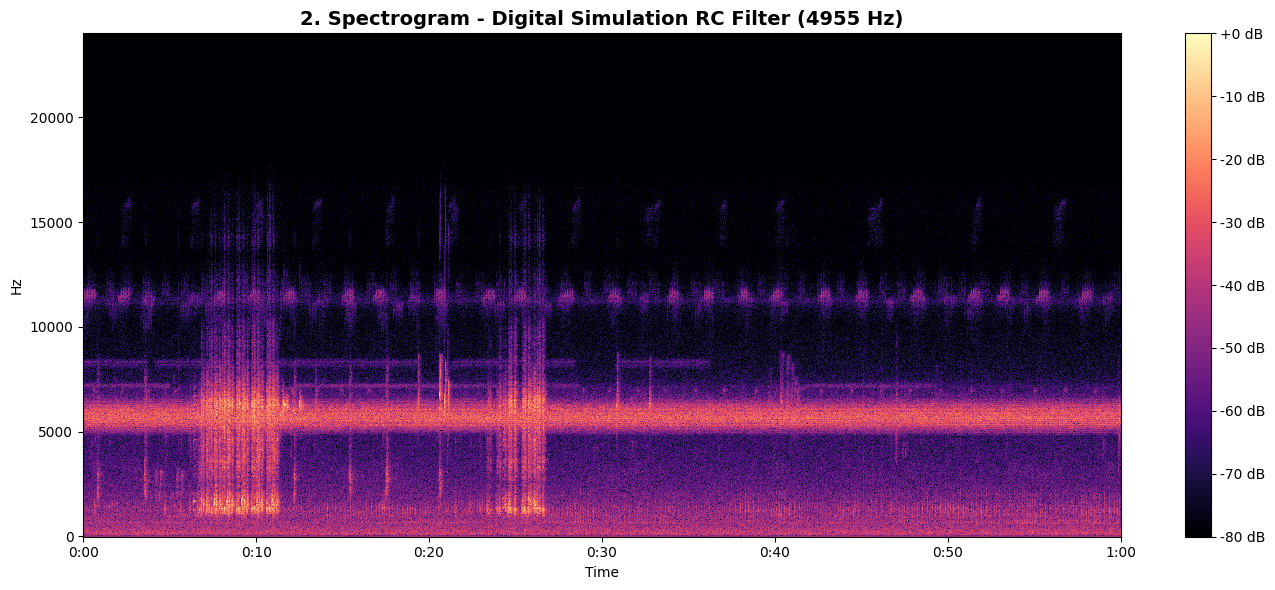

In [2]:
AUDIO_FILE = r'C:\Users\ggrmi\Documents\CricketKiller-data\IDSM_SMM00894_20230816_064000_biophony=technophony_morning.wav'
SAMPLE_RATE = 48000

raw_audio, _ = librosa.load(AUDIO_FILE, sr=SAMPLE_RATE, mono=True)

# 1. Plot the Original Audio Spectrogram
plot_spectrogram(raw_audio, SAMPLE_RATE, "1. Spectrogram - Original Raw Audio")

# -----------------------------------------------------------------------
# DIGITAL SIMULATION (1st Order RC Filter)
# -----------------------------------------------------------------------
CUTOFF_FREQ = 4955  # Cutoff frequency in Hz

# Apply the simulated analog filter
digital_filtered_audio = apply_filter(audio=raw_audio, high_cutoff=CUTOFF_FREQ, sr=SAMPLE_RATE)

save(
    audio_data=digital_filtered_audio, 
    sr=SAMPLE_RATE, 
    pasta_destino='./resultados_circuitos',
    nome_arquivo='passa-baixas_saida_digital'
)

plot_spectrogram(
    digital_filtered_audio, 
    SAMPLE_RATE, 
    f"2. Spectrogram - Digital Simulation RC Filter ({CUTOFF_FREQ} Hz)"
)

# Resultado Analógico

Preparing to record for 62 seconds...
1. Run this cell.
2. Press PLAY on your phone audio IMMEDIATELY!

Signal recorded and normalized successfully! (Gain: 6.90x)
Audio saved successfully


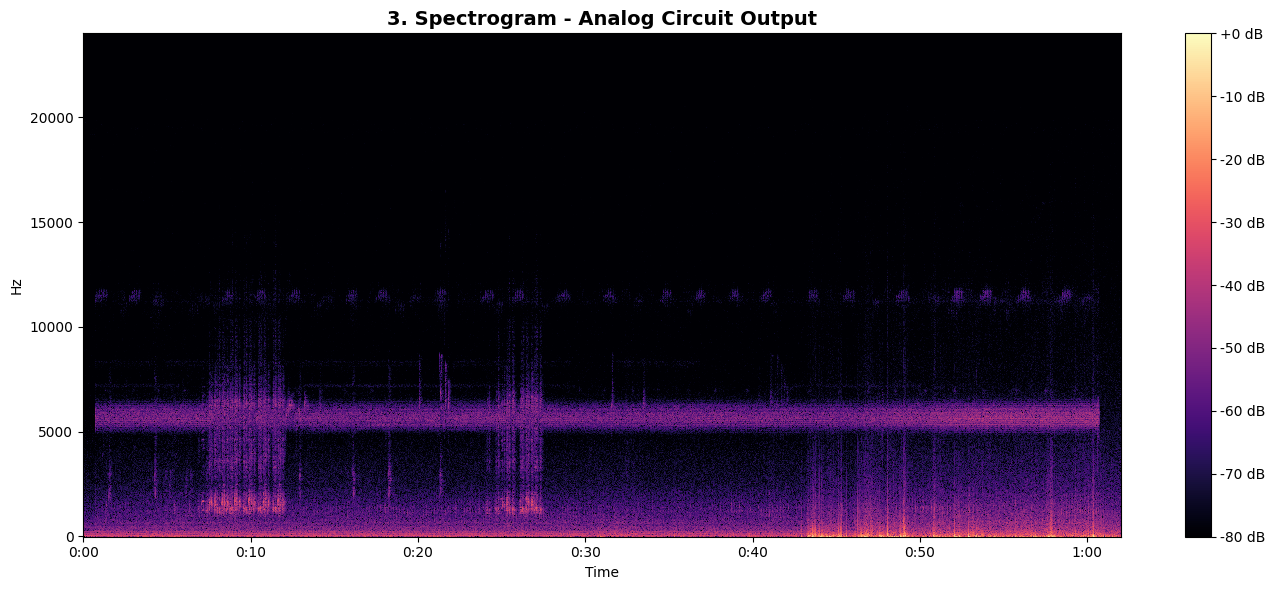

In [5]:
INPUT_ID = 12   # The Dell's P2 port ID
SAMPLE_RATE = 48000
RECORD_DURATION = 62  # Time in seconds (gives you time to press play on the phone)

print(f"Preparing to record for {RECORD_DURATION} seconds...")
print("1. Run this cell.")
print("2. Press PLAY on your phone audio IMMEDIATELY!")

# Record in stereo so the Windows driver accepts the connection
analog_raw_recording = sd.rec(
    int(RECORD_DURATION * SAMPLE_RATE), 
    samplerate=SAMPLE_RATE, 
    channels=2, 
    dtype='float32', 
    device=INPUT_ID
)

sd.wait()

# Extract Channel 0 (The Blue Wire / Tip)
analog_filtered_signal = analog_raw_recording[:, 0]

max_amp = np.max(np.abs(analog_filtered_signal))
if max_amp > 0:
    analog_filtered_signal = analog_filtered_signal / max_amp
    print(f"\nSignal recorded and normalized successfully! (Gain: {1/max_amp:.2f}x)")
else:
    print("\nTotal silence. The signal did not reach the port.")

save(
    audio_data=analog_filtered_signal, 
    sr=SAMPLE_RATE, 
    pasta_destino='./resultados_circuitos',
    nome_arquivo='passa-baixas_saida_analógica'
)

# 1. Plot the standard spectrogram of what the PC actually captured
plot_spectrogram(
    analog_filtered_signal, 
    SAMPLE_RATE, 
    "3. Spectrogram - Analog Circuit Output"
)